# BHARTIARTL Last 1 Year Overview

Loads BHARTIARTL data, keeps only the last 1 year, and shows Adj Close, drawdown, and daily return in one dual-axis line chart.

In [11]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.2f}".format

In [12]:
TICKER = "BHARTIARTL.NS"

candidate_paths = [
    Path("..").resolve() / "raw" / f"{TICKER}.csv",
    Path("large-cap") / "stock_analysis" / "data" / "raw" / f"{TICKER}.csv",
]
RAW_DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if RAW_DATA_PATH is None:
    raise FileNotFoundError(f"Could not find raw data for {TICKER}")

df = pd.read_csv(RAW_DATA_PATH, parse_dates=["Date"])
df = df.sort_values("Date").drop_duplicates("Date").set_index("Date")

price_col = "Adj Close" if "Adj Close" in df.columns else "Close"
start_date = df.index.max() - pd.DateOffset(years=1)
last_1y = df.loc[df.index >= start_date].copy()

last_1y["daily_return"] = last_1y[price_col].pct_change()
last_1y["running_max"] = last_1y[price_col].cummax()
last_1y["drawdown"] = last_1y[price_col] / last_1y["running_max"] - 1

last_1y.head()

,Open,High,Low,Close,Adj Close,Volume,daily_return,running_max,drawdown
Date,,,,,,,,,
2025-08-28,"1,893.00","1,899.80","1,878.20","1,881.10","1,857.72",5494113,NaN,"1,857.72",0.00
2025-08-29,"1,872.50","1,900.10","1,872.50","1,888.80","1,865.32",4339042,0.00,"1,865.32",0.00
2025-09-01,"1,889.00","1,904.80","1,884.20","1,900.60","1,876.98",3421488,0.01,"1,876.98",0.00
2025-09-02,"1,904.50","1,917.50","1,878.00","1,887.20","1,863.74",4423049,-0.01,"1,876.98",-0.01
2025-09-03,"1,891.00","1,892.10","1,870.00","1,883.90","1,860.49",3803044,-0.00,"1,876.98",-0.01


In [13]:
last_1y[[price_col, "daily_return", "drawdown"]].tail()

,Adj Close,daily_return,drawdown
Date,,,
2026-08-24,"1,935.00",-0.01,-0.09
2026-08-25,"1,947.00",0.01,-0.09
2026-08-26,"1,902.10",-0.02,-0.11
2026-08-27,"1,878.30",-0.01,-0.12
2026-08-28,"1,882.40",0.00,-0.12


## Dual-Axis Last 1 Year Plot

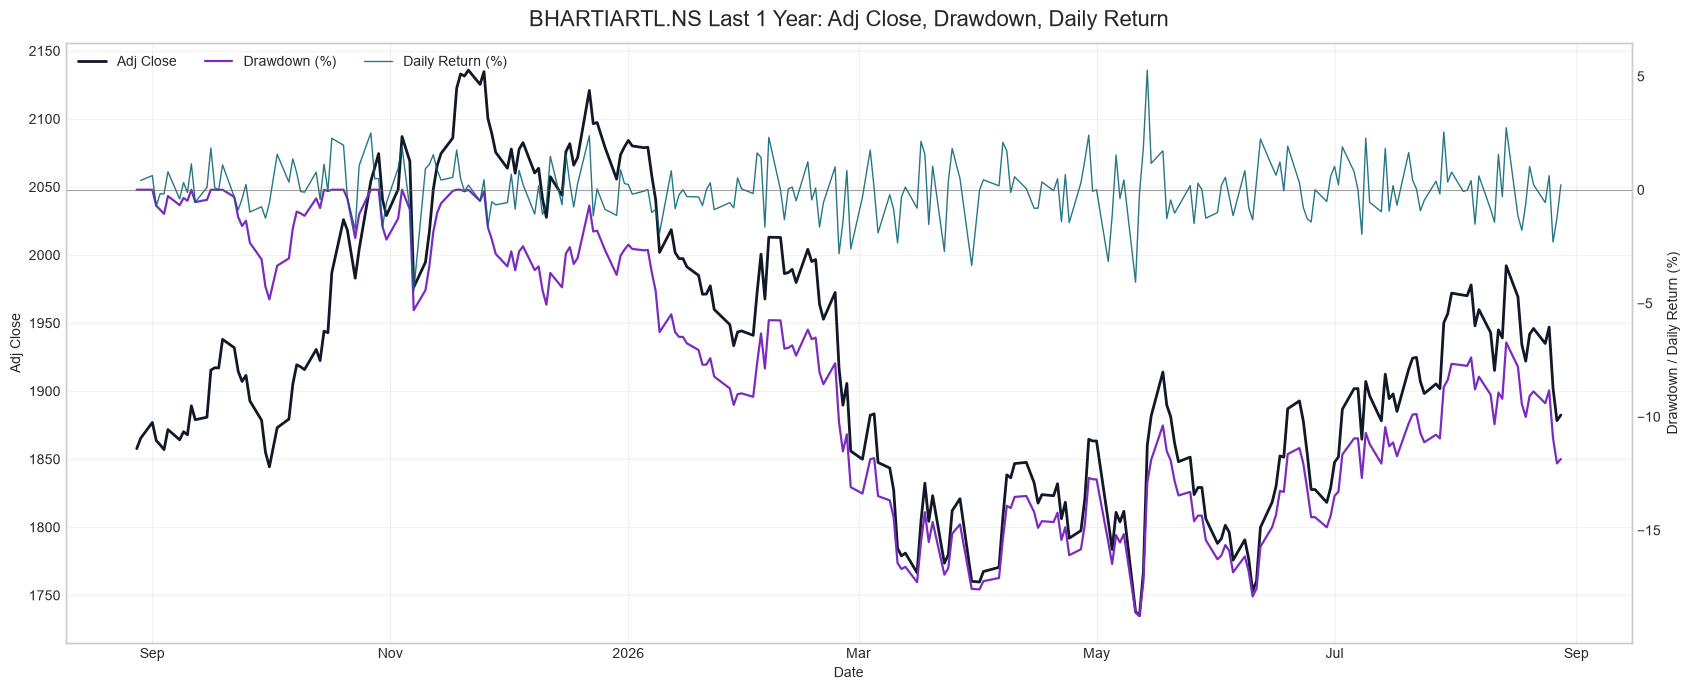

In [14]:
fig, ax_price = plt.subplots(figsize=(17, 7))
ax_metrics = ax_price.twinx()

adj_close_line = ax_price.plot(
    last_1y.index,
    last_1y[price_col],
    label=price_col,
    color="#111827",
    linewidth=2.0,
)
drawdown_line = ax_metrics.plot(
    last_1y.index,
    last_1y["drawdown"] * 100,
    label="Drawdown (%)",
    color="#7b2cbf",
    linewidth=1.6,
)
daily_return_line = ax_metrics.plot(
    last_1y.index,
    last_1y["daily_return"] * 100,
    label="Daily Return (%)",
    color="#005f73",
    linewidth=1.0,
    alpha=0.85,
)

ax_metrics.axhline(0, color="#666666", linewidth=0.8, alpha=0.6)
ax_price.set_title(f"{TICKER} Last 1 Year: Adj Close, Drawdown, Daily Return", fontsize=16, pad=12)
ax_price.set_ylabel(f"{price_col}")
ax_metrics.set_ylabel("Drawdown / Daily Return (%)")

lines = adj_close_line + drawdown_line + daily_return_line
labels = [line.get_label() for line in lines]
ax_price.legend(lines, labels, loc="upper left", ncol=3)

date_locator = mdates.AutoDateLocator()
ax_price.xaxis.set_major_locator(date_locator)
ax_price.xaxis.set_major_formatter(mdates.ConciseDateFormatter(date_locator))
ax_price.set_xlabel("Date")
ax_price.grid(True, alpha=0.25)
ax_metrics.grid(False)

fig.tight_layout()

In [15]:
summary = pd.Series(
    {
        "start_date": last_1y.index.min().date(),
        "end_date": last_1y.index.max().date(),
        "rows": len(last_1y),
        "last_adj_close": last_1y[price_col].iloc[-1],
        "one_year_return_pct": (last_1y[price_col].iloc[-1] / last_1y[price_col].iloc[0] - 1) * 100,
        "max_drawdown_pct": last_1y["drawdown"].min() * 100,
        "avg_daily_return_pct": last_1y["daily_return"].mean() * 100,
    }
)

summary

start_date              2025-08-28
end_date                2026-08-28
rows                           252
last_adj_close            1,882.40
one_year_return_pct           1.33
max_drawdown_pct            -18.77
avg_daily_return_pct          0.01
dtype: object